In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix,r2_score, explained_variance_score, mean_absolute_error, mean_squared_error,roc_auc_score,accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from feature_engine.encoding import OneHotEncoder 

In [2]:
#removing punctuation from messages(reviews)
def message_cleaning(message):
    test_punc_removed = [char for char in message if char not in string.punctuation]
    test_punc_removed_join = ''.join(test_punc_removed)
    test_punc_removed_join_clean = [word for word in test_punc_removed_join.split() if word.lower() not in stopwords.words('english')]
    return test_punc_removed_join_clean

# function with different metrics to evaluate train model
def evaluating_the_train_model(y_train, y_predict_train):
    
    print('Classification report train set')
    print(classification_report(y_train, y_predict_train))
    print()
    
    print('r2 squared error train set:',r2_score(y_train, y_predict_train))
    print('explained variance score train set:',explained_variance_score(y_train, y_predict_train))
    print('mean absolute error train set:',mean_absolute_error(y_train, y_predict_train))
    print('mean squared error  train set:',mean_squared_error(y_train, y_predict_train))
    print('roc-auc score: {}'.format(roc_auc_score(y_train, y_predict_train)))
    print()
    
    print('Confusion matrix train set')
    cm = confusion_matrix(y_train, y_predict_train)
    sns.heatmap(cm, annot = True)
    
    
# function with different metrics to evaluate test model    
def evaluating_the_test_model(y_test, y_predict_test):
    
    print('Classification report test set')
    print(classification_report(y_test, y_predict_test))
    print()
    
    print('r2 squared error test set:',r2_score(y_test, y_predict_test))
    print('explained variance score test set:',explained_variance_score(y_test, y_predict_test))
    print('mean absolute error test set:',mean_absolute_error(y_test, y_predict_test))
    print('mean squared error test set:',mean_squared_error(y_test, y_predict_test))
    print('roc-auc score: {}'.format(roc_auc_score(y_test, y_predict_test)))
    print()
    
    print('Confusion matrix test set')
    cm = confusion_matrix(y_test, y_predict_test)
    sns.heatmap(cm, annot = True)
    

#predicting model and evaluating it with metrics
def metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model):
    
    y_predict_train = classifier.predict(X_train)
    y_predict_test = classifier.predict(X_test)
    print(name_of_the_model)
    print('Train set')
    evaluating_the_train_model(y_train, y_predict_train)
    pred = classifier.predict_proba(X_train)
    train_roc_auc_proba = roc_auc_score(y_train,pred[:,1])
    print(name_of_the_model+ ' train roc-auc with predict_proba: {}'.format(train_roc_auc_proba))
    print()
    
    print('Test set')
    evaluating_the_test_model(y_test, y_predict_test)
    pred = classifier.predict_proba(X_test)
    test_roc_auc_proba = roc_auc_score(y_test,pred[:,1])
    print(name_of_the_model+ ' test roc-auc with predict_proba: {}'.format(test_roc_auc_proba))
    print()
    
    train_roc_auc[name_of_the_model] = train_roc_auc_proba
    test_roc_auc[name_of_the_model] = test_roc_auc_proba

#looking for the best parameters with grid search
def grid_search_best_parameters(classifier, parameters, X_train, y_train,name_of_the_model):
     
    grid_search = GridSearchCV(
            estimator = classifier, 
            param_grid = parameters,
            scoring = 'accuracy',
            cv = 10,
            n_jobs = -1)

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_
    
    best_accuracy_with_best_parameters[name_of_the_model] = best_accuracy * 100


In [3]:
#models results
train_roc_auc = dict()
test_roc_auc = dict()
best_accuracy_with_best_parameters = dict()

In [4]:
data = pd.read_csv('../yelp_classification/yelp.csv')
data.head(10)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0
5,-yxfBYGB6SEqszmxJxd97A,2007-12-13,m2CKSsepBCoRYWxiRUsxAg,4,"Quiessence is, simply put, beautiful. Full wi...",review,sqYN3lNgvPbPCTRsMFu27g,4,3,1
6,zp713qNhx8d9KCJJnrw1xA,2010-02-12,riFQ3vxNpP4rWLk_CSri2A,5,Drop what you're doing and drive here. After I...,review,wFweIWhv2fREZV_dYkz_1g,7,7,4
7,hW0Ne_HTHEAgGF1rAdmR-g,2012-07-12,JL7GXJ9u4YMx7Rzs05NfiQ,4,"Luckily, I didn't have to travel far to make m...",review,1ieuYcKS7zeAv_U15AB13A,0,1,0
8,wNUea3IXZWD63bbOQaOH-g,2012-08-17,XtnfnYmnJYi71yIuGsXIUA,4,Definitely come for Happy hour! Prices are ama...,review,Vh_DlizgGhSqQh4qfZ2h6A,0,0,0
9,nMHhuYan8e3cONo3PornJA,2010-08-11,jJAIXA46pU1swYyRCdfXtQ,5,Nobuo shows his unique talents with everything...,review,sUNkXg8-KFtCMQDV6zRzQg,0,1,0


In [5]:
data.describe()

,stars,cool,useful,funny
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.777500,0.876800,1.409300,0.701300
std,1.214636,2.067861,2.336647,1.907942
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000
75%,5.000000,1.000000,2.000000,1.000000
max,5.000000,77.000000,76.000000,57.000000


## Description of features:
* business_id: unique identification number of business
* date: date of review
* review_id: uniqueidentification number of review
* stars: the rate of service/product given by reviewer from 1 to 5
* text: the review text 
* type: type of review [review]
* user_id:unique identification number of reviewer
* cool,useful,funny: characteristics of review which count number of other Yelp users reaction on review


In [6]:
data.shape , data.dtypes # size of dataset,types of values

((10000, 10),
 business_id    object
 date           object
 review_id      object
 stars           int64
 text           object
 type           object
 user_id        object
 cool            int64
 useful          int64
 funny           int64
 dtype: object)

In [7]:
data.isnull().mean()*100 # missing value in percentage (NO MISSING VALUES)

business_id    0.0
date           0.0
review_id      0.0
stars          0.0
text           0.0
type           0.0
user_id        0.0
cool           0.0
useful         0.0
funny          0.0
dtype: float64

In [8]:
for var in ['stars','cool','useful','funny','type']:
    print (var, data[var].unique()[0:], '\n') #checking unique values of some features to understand dataset

stars [5 4 2 3 1] 

cool [ 2  0  1  4  7  3  5 11  6  8 16 28 12 13 10 22 17 18  9 14 21 15 19 20
 23 77 27 38 32] 

useful [ 5  0  1  2  3  7  4  6 16  9 17 19 28  8 15 10 12 23 20 11 13 18 14 24
 76 31 38 30] 

funny [ 0  1  4  2  3  8  9  6  5 39  7 12 16 20 27 11 13 17 10 30 22 14 19 18
 23 21 15 24 57] 

type ['review'] 



In [9]:
# to understand better situation with review lets calculate the lenght of review text
data['length'] = data['text'].apply(len)
data.head(10)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,length
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,889
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0,1345
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0,76
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0,419
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0,469
5,-yxfBYGB6SEqszmxJxd97A,2007-12-13,m2CKSsepBCoRYWxiRUsxAg,4,"Quiessence is, simply put, beautiful. Full wi...",review,sqYN3lNgvPbPCTRsMFu27g,4,3,1,2094
6,zp713qNhx8d9KCJJnrw1xA,2010-02-12,riFQ3vxNpP4rWLk_CSri2A,5,Drop what you're doing and drive here. After I...,review,wFweIWhv2fREZV_dYkz_1g,7,7,4,1565
7,hW0Ne_HTHEAgGF1rAdmR-g,2012-07-12,JL7GXJ9u4YMx7Rzs05NfiQ,4,"Luckily, I didn't have to travel far to make m...",review,1ieuYcKS7zeAv_U15AB13A,0,1,0,274
8,wNUea3IXZWD63bbOQaOH-g,2012-08-17,XtnfnYmnJYi71yIuGsXIUA,4,Definitely come for Happy hour! Prices are ama...,review,Vh_DlizgGhSqQh4qfZ2h6A,0,0,0,349
9,nMHhuYan8e3cONo3PornJA,2010-08-11,jJAIXA46pU1swYyRCdfXtQ,5,Nobuo shows his unique talents with everything...,review,sUNkXg8-KFtCMQDV6zRzQg,0,1,0,186


<Axes: ylabel='Frequency'>

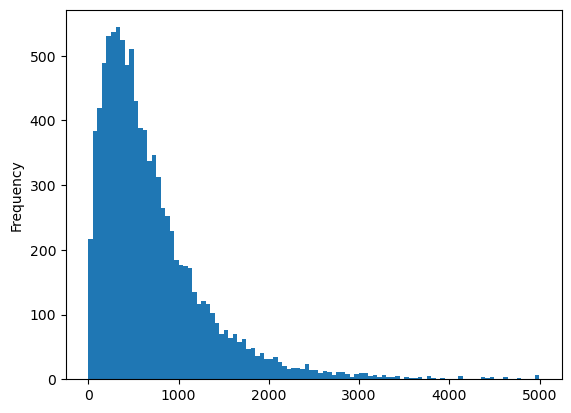

In [10]:
data['length'].plot(bins = 100, kind = 'hist') #the most reviews are under 1000 symbols

<Axes: xlabel='count', ylabel='stars'>

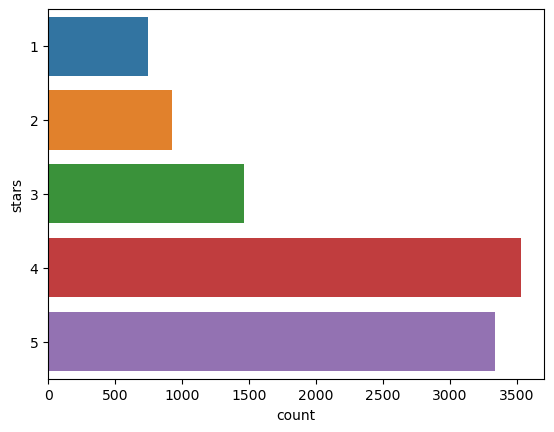

In [11]:
# Since this is classification problem lets more explore 'stars' feature #ДОБАВИТЬ ПРОЦЕНТЫ
sns.countplot(y = 'stars', data = data)

In [12]:
# first of all we can see that the most reviews are positive (4 and 5 stars)

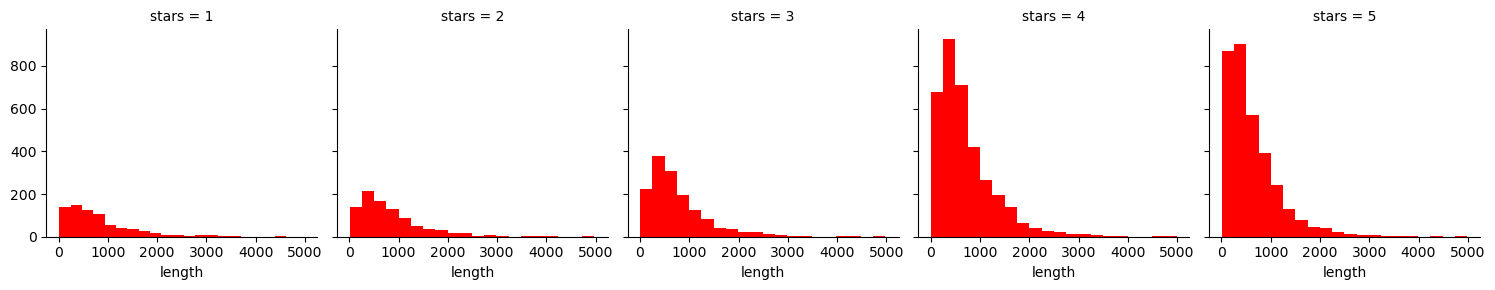

In [13]:
#then lets check lenghts of every 'star' review
g = sns.FacetGrid(data = data, col ='stars', col_wrap= 5)
g.map(plt.hist, 'length', bins = 20, color = 'r')

In [14]:
#lets create dataset with 1 and 5 stars review because we can train model only on positive and negative cases
yelp_df_1_5 = pd.concat([data[data['stars']==1],data[data['stars']==5]])
yelp_df_1_5

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,length
23,IJ0o6b8bJFAbG6MjGfBebQ,2010-09-05,Dx9sfFU6Zn0GYOckijom-g,1,U can go there n check the car out. If u wanna...,review,zRlQEDYd_HKp0VS3hnAffA,0,1,1,594
31,vvA3fbps4F9nGlAEYKk_sA,2012-05-04,S9OVpXat8k5YwWCn6FAgXg,1,Disgusting! Had a Groupon so my daughter and ...,review,8AMn6644NmBf96xGO3w6OA,0,1,0,361
35,o1GIYYZJjM6nM03fQs_uEQ,2011-11-30,ApKbwpYJdnhhgP4NbjQw2Q,1,"I've eaten here many times, but none as bad as...",review,iwUN95LIaEr75TZE_JC6bg,0,4,3,1198
61,l4vBbCL9QbGiwLuLKwD_bA,2011-11-22,DJVxOfj2Rw9zklC9tU3i1w,1,I have always been a fan of Burlington's deals...,review,EPROVap0M19Y6_4uf3eCmQ,0,0,0,569
64,CEswyP-9SsXRNLR9fFGKKw,2012-05-19,GXj4PNAi095-q9ynPYH3kg,1,Another night meeting friends here. I have to...,review,MjLAe48XNfYlTeFYca5gMw,0,1,2,498
...,...,...,...,...,...,...,...,...,...,...,...
9990,R8VwdLyvsp9iybNqRvm94g,2011-10-03,pcEeHdAJPoFNF23es0kKWg,5,Yes I do rock the hipster joints. I dig this ...,review,b92Y3tyWTQQZ5FLifex62Q,1,1,1,263
9991,WJ5mq4EiWYAA4Vif0xDfdg,2011-12-05,EuHX-39FR7tyyG1ElvN1Jw,5,Only 4 stars? \n\n(A few notes: The folks that...,review,hTau-iNZFwoNsPCaiIUTEA,1,1,0,908
9992,f96lWMIAUhYIYy9gOktivQ,2009-03-10,YF17z7HWlMj6aezZc-pVEw,5,I'm not normally one to jump at reviewing a ch...,review,W_QXYA7A0IhMrvbckz7eVg,2,3,2,1326
9994,L3BSpFvxcNf3T_teitgt6A,2012-03-19,0nxb1gIGFgk3WbC5zwhKZg,5,Let's see...what is there NOT to like about Su...,review,OzOZv-Knlw3oz9K5Kh5S6A,1,2,1,1968


In [15]:
yelp_df_1_5['positive'] =np.where(yelp_df_1_5['stars']== 5, 1, 0)
yelp_df_1_5.tail(50)

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,length,positive
9871,GAPqG0WNBBidKeZTMpEZ-w,2010-12-27,DPhy3dRkmhiphPD57j7Vtg,5,I have been here at least 10 times and have ne...,review,yg9FlyXJcmrMAfqkXmVvDw,0,0,0,256,1
9878,cN6aBxe2mQvrQlzk26LyRQ,2012-05-27,i01x8QygrEUch4fiKIeuJA,5,Heard about this interesting steak house from ...,review,GNlv9XPhj6P8Fk8Z0cnBrw,0,2,0,604,1
9880,1nIf2BoKPoNHbQKbi-Izig,2012-08-08,CcAQODU1Z3-Q_GvqoZEP1g,5,Fable III used AND looks brand new for $11?! ...,review,S-07w5CJfDmEBTNZ9V-ycw,5,6,3,1013,1
9884,qMkIbQFrROSnPaQ7at85-w,2012-07-06,JmRsNK6lSO-_aAw-YnfWXg,5,I love this place I have been here 2wice and i...,review,Hlhcx4gPu4jmTalbZLNc5A,0,0,0,125,1
9892,eIxSLxzIlfExI6vgAbn2JA,2012-08-01,ewv4dzX4GlYCwZdyHOP55Q,5,"Loved it. Food was great, service was great. N...",review,ksJmOji5HBELowhDLGm_3g,0,1,0,86,1
9894,rZbHg4ACfN3iShdsT47WKQ,2011-01-13,nm-KyaVBNZJSEGYLLdt-EQ,5,I'm giving Bobby Q an extra star in this updat...,review,A_VCj_m1zqW0gc0zSzQ3tA,1,2,0,1150,1
9896,eIxSLxzIlfExI6vgAbn2JA,2010-04-10,b01QqdMpIIaeEnMs_g92pQ,5,Headed back to Lobby's. How I missed this tast...,review,9qCPmT6ovJjxL4tJB4ANCg,2,3,1,561,1
9897,vSEFzop2GDXsIWTLxIGMiw,2010-08-06,we5T3NsdF_oPrbPBpMo31w,5,Rivas helped me get through numerous late nigh...,review,2tyadgcxcaEu5LWgLdwLAQ,0,0,0,234,1
9899,byFWmwlVSmUj-AmM6NZYvw,2007-12-27,oS3wR-c59yIWUI1BLccv6w,5,http://www.in-n-out.com/secretmenu.asp\nhttp:/...,review,wi2DEAkDI2AbVF4PBELEzQ,0,1,0,420,1
9900,BINYfrtGp3A4w0d5E7kbYw,2011-01-07,Al1aLymjMR_wYiYcNR26CQ,5,"Soft opening, so still working out the kinks. ...",review,2lvfBteL5ny4CBjNIk9Mwg,0,0,0,432,1


In [16]:
yelp_df_1_5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4086 entries, 23 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  4086 non-null   object
 1   date         4086 non-null   object
 2   review_id    4086 non-null   object
 3   stars        4086 non-null   int64 
 4   text         4086 non-null   object
 5   type         4086 non-null   object
 6   user_id      4086 non-null   object
 7   cool         4086 non-null   int64 
 8   useful       4086 non-null   int64 
 9   funny        4086 non-null   int64 
 10  length       4086 non-null   int64 
 11  positive     4086 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 415.0+ KB


1-stars percentage = 18.330885952031327 %
5-stars percentage = 81.66911404796868 %


<Axes: xlabel='stars', ylabel='count'>

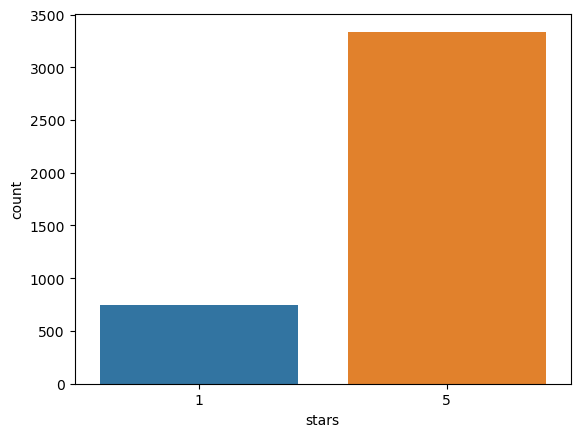

In [17]:
print('1-stars percentage = {} %'.format((len(yelp_df_1_5[yelp_df_1_5['stars']==1])/len(yelp_df_1_5))*100))
print('5-stars percentage = {} %'.format((len(yelp_df_1_5[yelp_df_1_5['stars']==5])/len(yelp_df_1_5))*100))
sns.countplot(x = yelp_df_1_5['stars'], label = 'Count') #%%% disbalanced

In [18]:
#checkig correlation matrix
df_correlation = yelp_df_1_5.corr(numeric_only= True)
df_correlation

,stars,cool,useful,funny,length,positive
stars,1.000000,0.060861,-0.033213,-0.088261,-0.129617,1.000000
cool,0.060861,1.000000,0.899352,0.689206,0.223074,0.060861
useful,-0.033213,0.899352,1.000000,0.675535,0.287143,-0.033213
funny,-0.088261,0.689206,0.675535,1.000000,0.263126,-0.088261
length,-0.129617,0.223074,0.287143,0.263126,1.000000,-0.129617
positive,1.000000,0.060861,-0.033213,-0.088261,-0.129617,1.000000


<Axes: >

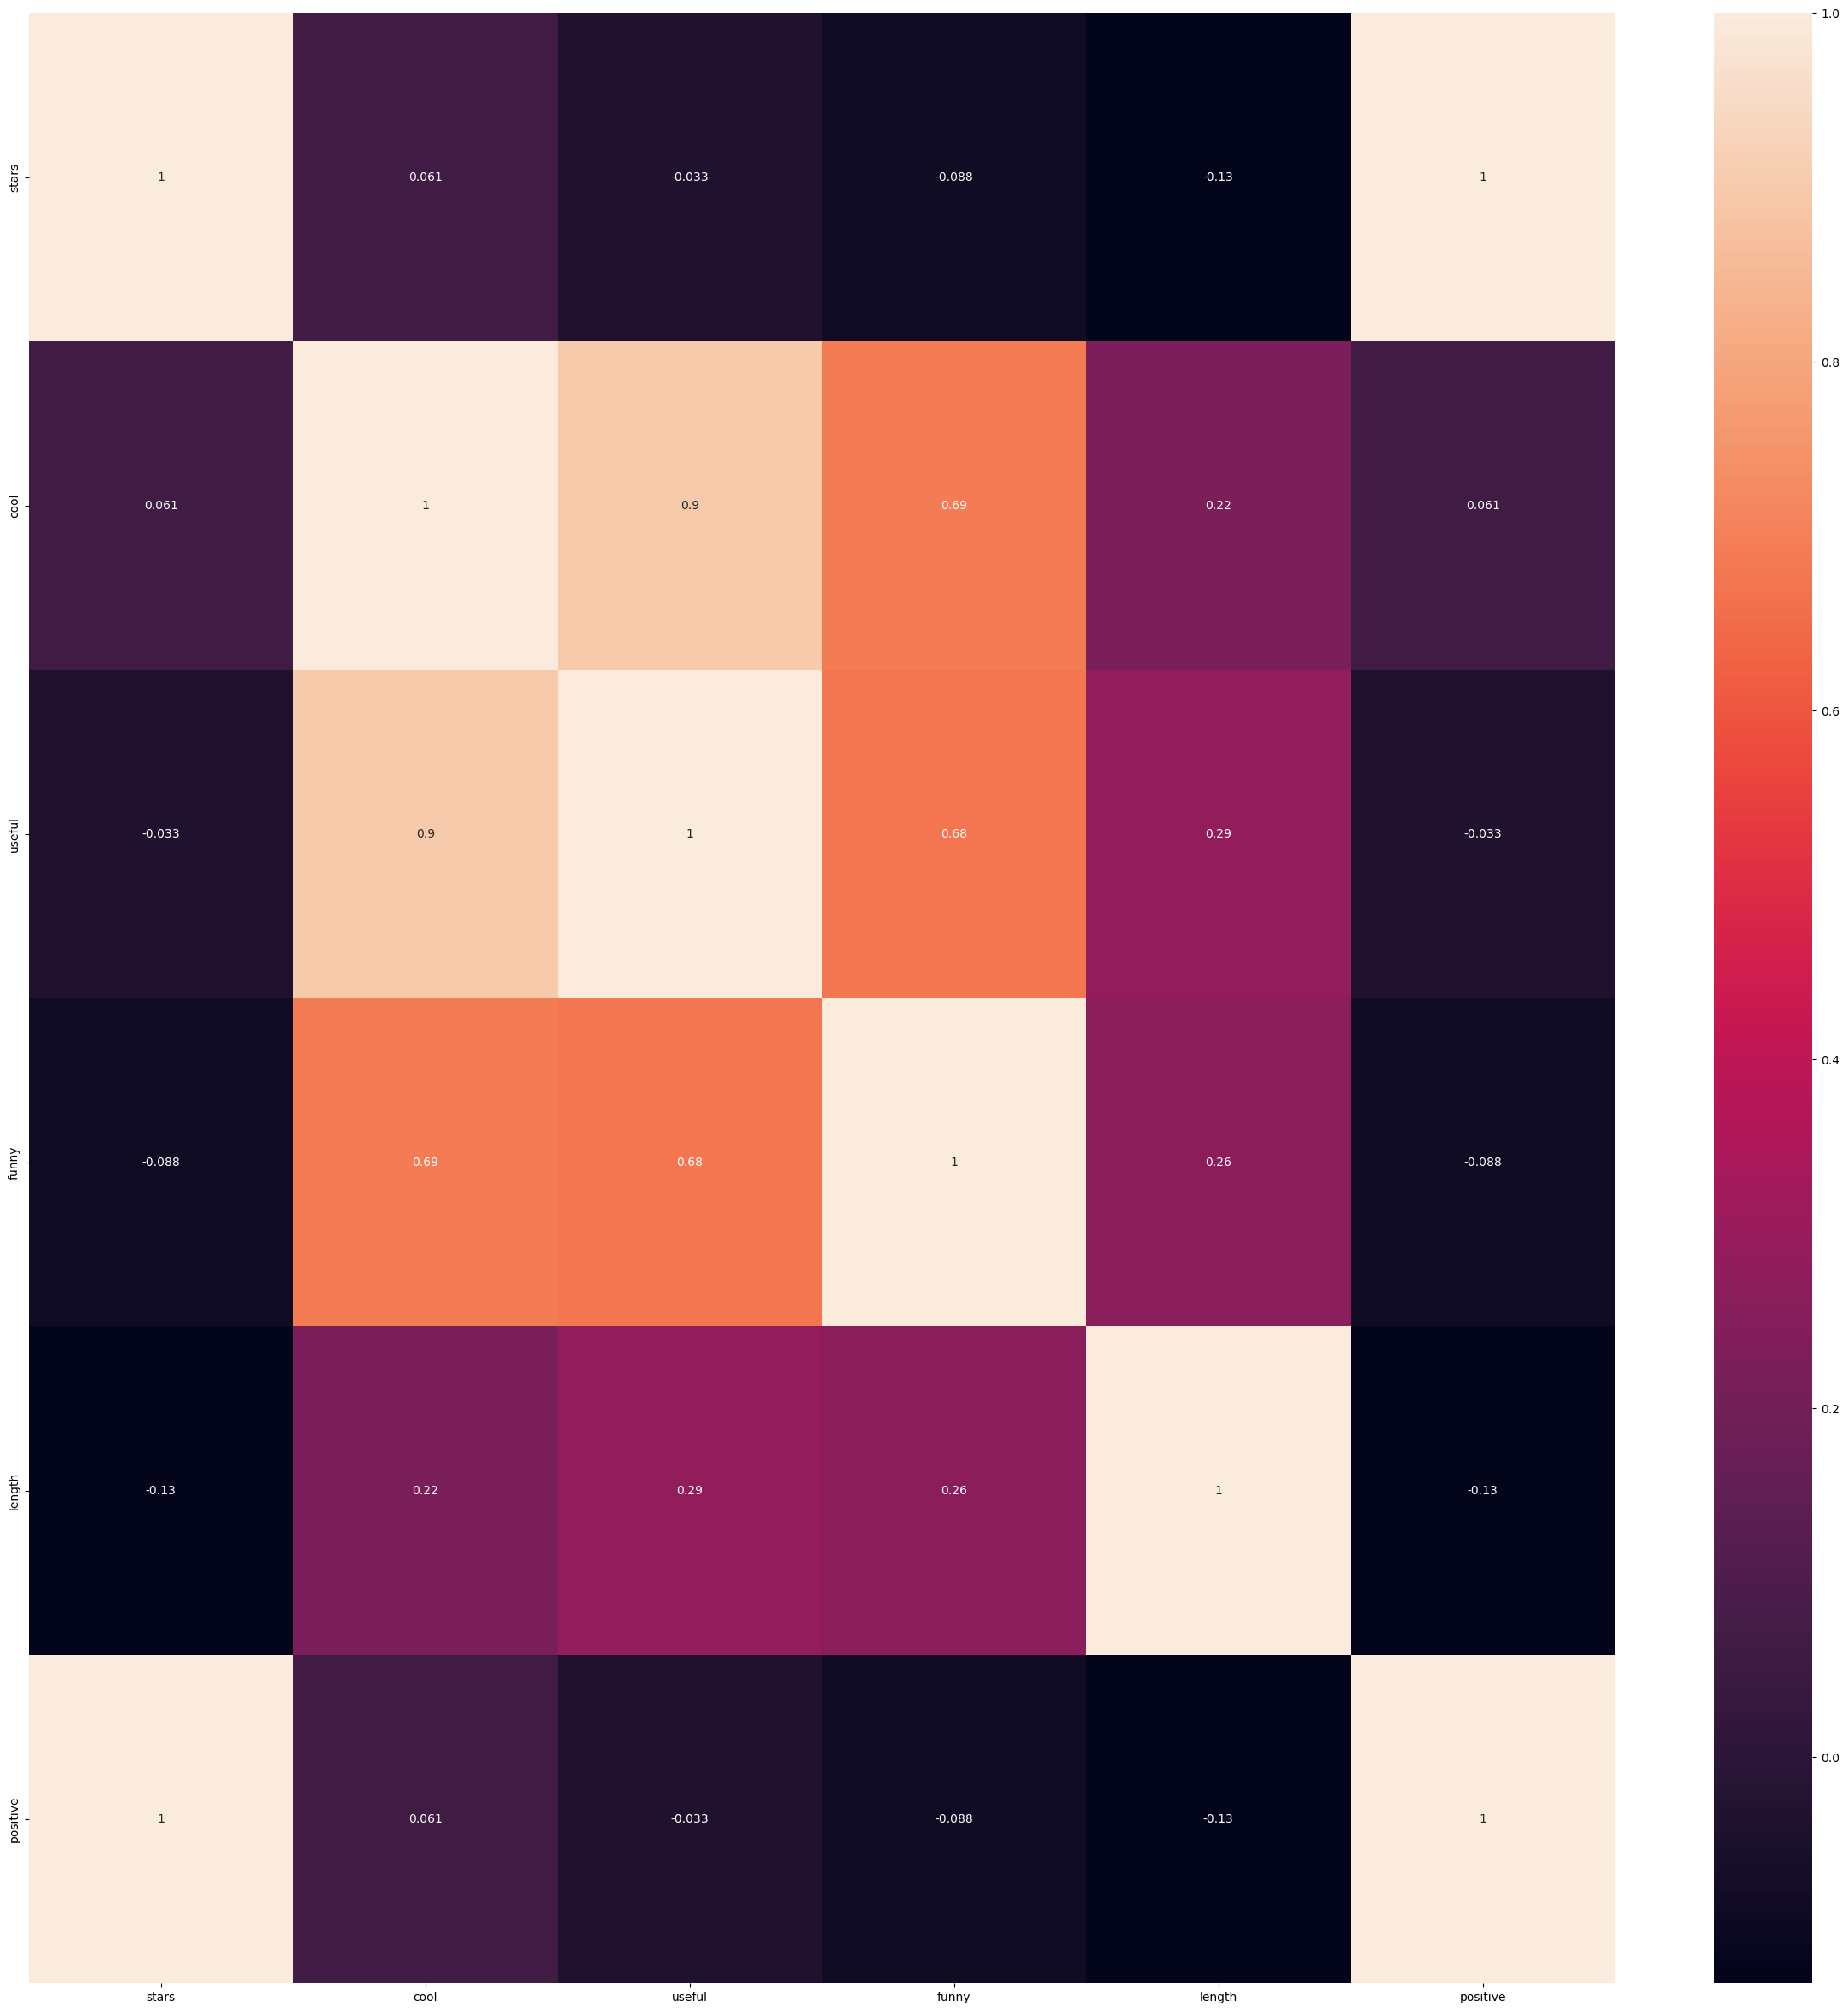

In [19]:
#visualizing correlated matrix
plt.figure(figsize=(30,30))
sns.heatmap(df_correlation, annot = True)

In [20]:
#according to correlation matrix we can drop high corelated features but it doesnt make sense for the next steps
yelp_df_1_5 = yelp_df_1_5.drop(['stars','cool','useful','funny'],axis = 1)
yelp_df_1_5.head(5)

,business_id,date,review_id,text,type,user_id,length,positive
23,IJ0o6b8bJFAbG6MjGfBebQ,2010-09-05,Dx9sfFU6Zn0GYOckijom-g,U can go there n check the car out. If u wanna...,review,zRlQEDYd_HKp0VS3hnAffA,594,0
31,vvA3fbps4F9nGlAEYKk_sA,2012-05-04,S9OVpXat8k5YwWCn6FAgXg,Disgusting! Had a Groupon so my daughter and ...,review,8AMn6644NmBf96xGO3w6OA,361,0
35,o1GIYYZJjM6nM03fQs_uEQ,2011-11-30,ApKbwpYJdnhhgP4NbjQw2Q,"I've eaten here many times, but none as bad as...",review,iwUN95LIaEr75TZE_JC6bg,1198,0
61,l4vBbCL9QbGiwLuLKwD_bA,2011-11-22,DJVxOfj2Rw9zklC9tU3i1w,I have always been a fan of Burlington's deals...,review,EPROVap0M19Y6_4uf3eCmQ,569,0
64,CEswyP-9SsXRNLR9fFGKKw,2012-05-19,GXj4PNAi095-q9ynPYH3kg,Another night meeting friends here. I have to...,review,MjLAe48XNfYlTeFYca5gMw,498,0


## Lets apply count vectorizer to our YELP reviews example

In [21]:
vectorizer = CountVectorizer(analyzer= message_cleaning)
yelp_countVectorizer = vectorizer.fit_transform(yelp_df_1_5['text'])

In [22]:
len(vectorizer.get_feature_names_out())

26435

##  Divide the data into training and testing prior to training

In [23]:
X = yelp_countVectorizer
y = yelp_df_1_5['positive'].values

X.shape, y.shape

((4086, 26435), (4086,))

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0)
X_train.shape, X_test.shape

((3268, 26435), (818, 26435))

In [25]:
def run_MultinomialNB(X_train, X_test, y_train, y_test):
    
    name_of_the_model = 'Multonomial NB'
    classifier = MultinomialNB()
    classifier.fit(X_train, y_train)
    
    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'alpha': [0.00001, 0.0001, 0.001, 0.1, 1, 10, 100,1000]
             }
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    
    
    
def run_DecisionTreeClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Decision tree'
    classifier = DecisionTreeClassifier(criterion= 'entropy', random_state= 0)
    classifier.fit(X_train, y_train)
    
    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
   
    parameters = {
              'max_depth' : [2,4,6,8,10,12],
              'criterion' :['gini', 'entropy','log_loss']
             }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

    
def run_RandomForestClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Random forest'
    classifier = RandomForestClassifier(n_estimators= 10, 
                                    criterion= 'entropy', 
                                    random_state=0
                                       )

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters =   {
        'n_estimators': [200, 500],
        'max_depth' : [4,5,6,7,8],
        'criterion' :['gini', 'entropy', 'log_loss']
     }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    
def run_AdaBoostClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Ada boost'
    classifier = AdaBoostClassifier(
        n_estimators=100, 
        learning_rate= 1.0,
        algorithm="SAMME", 
        random_state=0)

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'learning_rate':  [0.5,1.0,1.5,2.0],
        'n_estimators': [10,50,100,300,500]
             }
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    

def run_SVC(X_train, X_test, y_train, y_test):
    name_of_the_model = 'SVC'
    classifier = SVC(kernel= 'linear', random_state = 0, probability= True)
    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
         'C': [0.25, 0.5, 0.75, 1],
         'kernel': ['linear', 'rbf'],
        'gamma':[0.1,0.2,0.3]
    }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    

    
def run_XGboost(X_train, X_test, y_train, y_test):
    name_of_the_model = 'XG Boost'
    classifier = XGBClassifier()
    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

Ada boost
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.94      0.43      0.59       576
           1       0.89      0.99      0.94      2692

    accuracy                           0.89      3268
   macro avg       0.91      0.71      0.76      3268
weighted avg       0.90      0.89      0.88      3268


r2 squared error train set: 0.2686689986792141
explained variance score train set: 0.33266068701502394
mean absolute error train set: 0.10618115055079559
mean squared error  train set: 0.10618115055079559
roc-auc score: 0.7097018429090309

Confusion matrix train set
Ada boost train roc-auc with predict_proba: 0.9427686328834406

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.89      0.38      0.53       173
           1       0.86      0.99      0.92       645

    accuracy                           0.86       818
   macro avg       0.87      0.

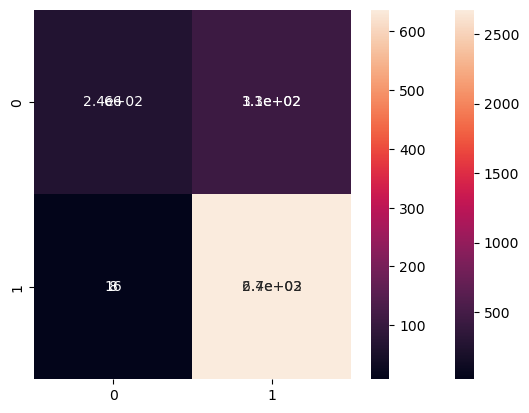

In [26]:
run_AdaBoostClassifier(X_train, X_test, y_train, y_test)

Multonomial NB
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       576
           1       0.98      1.00      0.99      2692

    accuracy                           0.98      3268
   macro avg       0.98      0.95      0.97      3268
weighted avg       0.98      0.98      0.98      3268


r2 squared error train set: 0.8672223254086181
explained variance score train set: 0.868770766262176
mean absolute error train set: 0.019277845777233783
mean squared error  train set: 0.019277845777233783
roc-auc score: 0.9500887403004787

Confusion matrix train set
Multonomial NB train roc-auc with predict_proba: 0.9963910558032029

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.88      0.69      0.77       173
           1       0.92      0.97      0.95       645

    accuracy                           0.91       818
   macro avg       0.

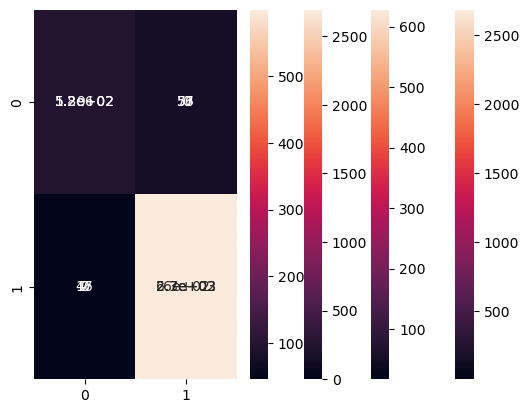

In [27]:
#training the models
run_MultinomialNB(X_train, X_test, y_train, y_test)
run_DecisionTreeClassifier(X_train, X_test, y_train, y_test)

Random forest
Train set
Classification report train set
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       576
           1       1.00      1.00      1.00      2692

    accuracy                           1.00      3268
   macro avg       1.00      0.99      0.99      3268
weighted avg       1.00      1.00      1.00      3268


r2 squared error train set: 0.9726014322271752
explained variance score train set: 0.9726794669390788
mean absolute error train set: 0.00397796817625459
mean squared error  train set: 0.00397796817625459
roc-auc score: 0.9893975978207032

Confusion matrix train set
Random forest train roc-auc with predict_proba: 0.9999193856281987

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.88      0.32      0.47       173
           1       0.84      0.99      0.91       645

    accuracy                           0.85       818
   macro avg       0.86 

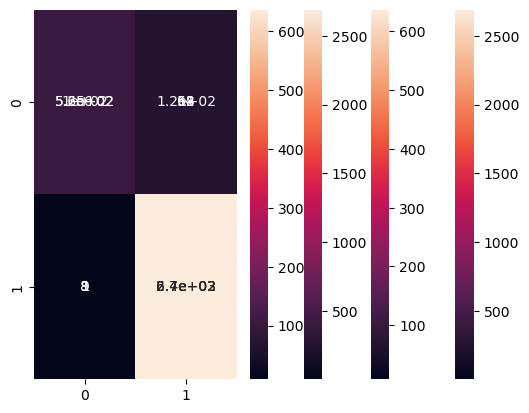

In [28]:
#training the models
run_RandomForestClassifier(X_train, X_test, y_train, y_test)
run_XGboost(X_train, X_test, y_train, y_test)

In [ ]:
#training the models

run_SVC(X_train, X_test, y_train, y_test)

SVC
Train set
Classification report train set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       576
           1       1.00      1.00      1.00      2692

    accuracy                           1.00      3268
   macro avg       1.00      1.00      1.00      3268
weighted avg       1.00      1.00      1.00      3268


r2 squared error train set: 0.9957848357272577
explained variance score train set: 0.9957874153871553
mean absolute error train set: 0.0006119951040391676
mean squared error  train set: 0.0006119951040391676
roc-auc score: 0.998263888888889

Confusion matrix train set
SVC train roc-auc with predict_proba: 1.0

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.81      0.71      0.75       173
           1       0.92      0.96      0.94       645

    accuracy                           0.90       818
   macro avg       0.87      0.83      0.85       818
we

## Comparing results of models training

In [ ]:
data = [
    train_roc_auc,
    test_roc_auc,
    best_accuracy_with_best_parameters
]

In [ ]:
results = pd.DataFrame(data)
results


# Creating final Pipeline

In [ ]:
yelp_df_1_5.head(3)

In [ ]:
X = yelp_df_1_5.drop('positive', axis = 'columns')
y = yelp_df_1_5['positive'].values

X.shape, y.shape

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0)
X_train.shape, X_test.shape

In [ ]:
text_vect = Pipeline([('vectorize', CountVectorizer(analyzer= message_cleaning))])

preprocess = ColumnTransformer([
                            ('text_vect', text_vect, 'text')
                        ])

pipeline = Pipeline([
                ('preprocess', preprocess),
                 ('training_best_model',XGBClassifier(
                     colsample_bytree = 0.6, 
                     gamma = 2, 
                     max_depth = 4, 
                     min_child_weight = 1,
                     subsample = 0.8))
])


In [ ]:
pipeline.fit(X_train, y_train)